Student Name : Perera M A S A

Student ID   : IT25103606

Feature **Standardization** using StandardScaler

Standardization -

Standardization is a preprocessing technique that transforms numeric
features so that they have approximately 0 mean and unit standard
deviation. I used StandardScaler because the plant sensor features
have very different numerical ranges

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import (
    GroupShuffleSplit,
    StratifiedGroupKFold,
    GridSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
uploaded = files.upload()

filename = next(iter(uploaded))
df = pd.read_csv(filename)

df.head()

Saving plant_health_data.csv to plant_health_data (1).csv


,Timestamp,Plant_ID,Soil_Moisture,Ambient_Temperature,Soil_Temperature,Humidity,Light_Intensity,Soil_pH,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Chlorophyll_Content,Electrochemical_Signal,Plant_Health_Status
0,2024-10-03 10:54:53.407995,1,27.521109,22.240245,21.900435,55.291904,556.172805,5.581955,10.003650,45.806852,39.076199,35.703006,0.941402,High Stress
1,2024-10-03 16:54:53.407995,1,14.835566,21.706763,18.680892,63.949181,596.136721,7.135705,30.712562,25.394393,17.944826,27.993296,0.164899,High Stress
2,2024-10-03 22:54:53.407995,1,17.086362,21.180946,15.392939,67.837956,591.124627,5.656852,29.337002,27.573892,35.706530,43.646308,1.081728,High Stress
3,2024-10-04 04:54:53.407995,1,15.336156,22.593302,22.778394,58.190811,241.412476,5.584523,16.966621,26.180705,26.257746,37.838095,1.186088,High Stress
4,2024-10-04 10:54:53.407995,1,39.822216,28.929001,18.100937,63.772036,444.493830,5.919707,10.944961,37.898907,37.654483,48.265812,1.609805,High Stress


In [3]:
print("Number of rows and columns:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nHealth status counts:")
print(df["Plant_Health_Status"].value_counts())

Number of rows and columns: (1200, 14)

Column names:
Index(['Timestamp', 'Plant_ID', 'Soil_Moisture', 'Ambient_Temperature',
       'Soil_Temperature', 'Humidity', 'Light_Intensity', 'Soil_pH',
       'Nitrogen_Level', 'Phosphorus_Level', 'Potassium_Level',
       'Chlorophyll_Content', 'Electrochemical_Signal', 'Plant_Health_Status'],
      dtype='object')

Missing values:
Timestamp                 0
Plant_ID                  0
Soil_Moisture             0
Ambient_Temperature       0
Soil_Temperature          0
Humidity                  0
Light_Intensity           0
Soil_pH                   0
Nitrogen_Level            0
Phosphorus_Level          0
Potassium_Level           0
Chlorophyll_Content       0
Electrochemical_Signal    0
Plant_Health_Status       0
dtype: int64

Duplicate rows:
0

Health status counts:
Plant_Health_Status
High Stress        500
Moderate Stress    401
Healthy            299
Name: count, dtype: int64


The data-quality check found no missing values and no exact duplicate rows. Therefore, no original observations were deleted or replaced during the initial cleaning stage. The target distribution is moderately imbalanced, with 500 High Stress, 401 Moderate Stress, and 299 Healthy observations.

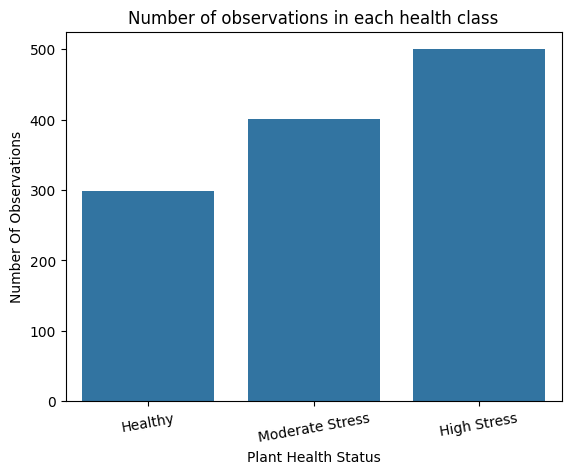

In [4]:
sns.countplot(
    data=df,
    x="Plant_Health_Status",
    order=["Healthy", "Moderate Stress", "High Stress"]
)

plt.title("Number of observations in each health class")
plt.xlabel("Plant Health Status")
plt.ylabel("Number Of Observations")
plt.xticks(rotation=10)
plt.show()

The count plot shows that High Stress is the largest class with 500 observations. Moderate Stress contains 401 observations, while Healthy is the smallest class with 299 observations. The classes are moderately imbalanced. Therefore, accuracy alone may not fully describe model performance, and metrics such as macro F1 should also be considered.

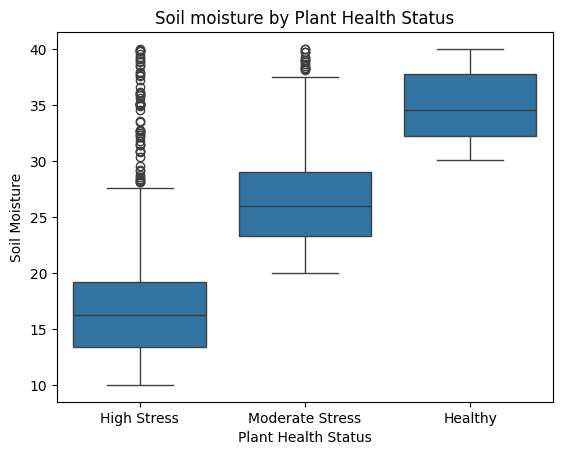

In [5]:
sns.boxplot(
    data=df,
    x="Plant_Health_Status",
    y="Soil_Moisture"
)

plt.title("Soil moisture by Plant Health Status")
plt.xlabel("Plant Health Status")
plt.ylabel("Soil Moisture")
plt.show()

The boxplot shows that Healthy observations generally have higher soil-moisture values. Moderate Stress observations generally appear in the middle, while High Stress observations generally have lower soil moisture. This suggests an association between soil moisture and plant health status in the assigned dataset. However, the visualization does not prove that soil moisture is the only cause of plant stress.

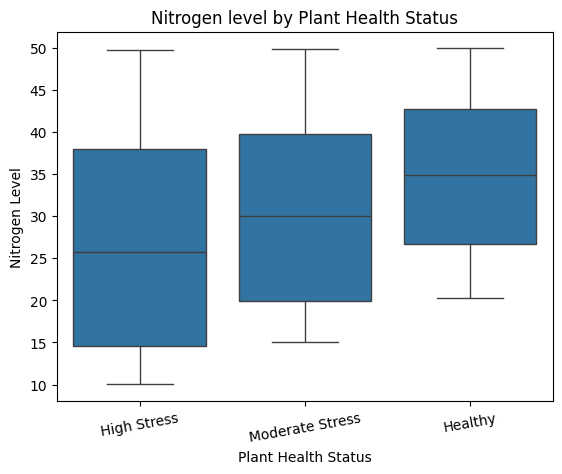

In [6]:
sns.boxplot(
    data=df,
    x="Plant_Health_Status",
    y="Nitrogen_Level"
)

plt.title("Nitrogen level by Plant Health Status")
plt.xlabel("Plant Health Status")
plt.ylabel("Nitrogen Level")
plt.xticks(rotation=10)
plt.show()

The Nitrogen level boxplot shows that Healthy observations generally have higher nitrogen measurements than High Stress observations. Moderate Stress generally appears between these groups. The classes still overlap, which indicates that nitrogen should be considered together with other sensor features rather than used as the only predictor.

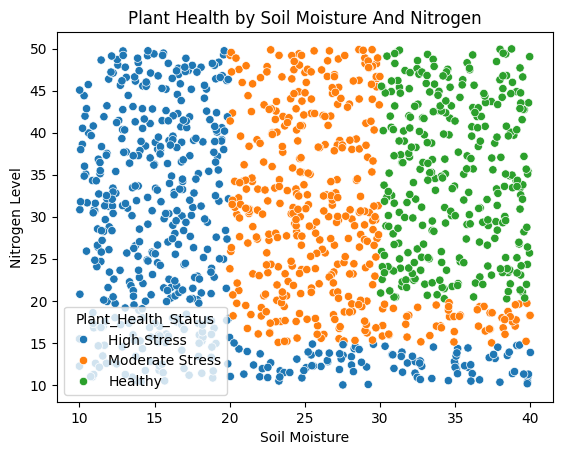

In [7]:
sns.scatterplot(
    data=df,
    x="Soil_Moisture",
    y="Nitrogen_Level",
    hue="Plant_Health_Status"
)

plt.title("Plant Health by Soil Moisture And Nitrogen")
plt.xlabel("Soil Moisture")
plt.ylabel("Nitrogen Level")
plt.show()

The Scatterplot shows that soil moisture provides strong separation between the three health classes. Nitrogen helps distinguish some observations that have similar soil moisture values. The pattern is not completely linear, which supports the investigation of nonlinear classification methods such as Decision Trees and RBF SVM.

In [8]:
target_column = "Plant_Health_Status"

y = df[target_column]
groups = df["Plant_ID"]

X = df.drop(
    columns=[
        target_column,
        "Plant_ID",
        "Timestamp"
    ]
)

print("Input columns:")
print(X.columns)

print("\nTarget classes:")
print(y.unique())

Input columns:
Index(['Soil_Moisture', 'Ambient_Temperature', 'Soil_Temperature', 'Humidity',
       'Light_Intensity', 'Soil_pH', 'Nitrogen_Level', 'Phosphorus_Level',
       'Potassium_Level', 'Chlorophyll_Content', 'Electrochemical_Signal'],
      dtype='object')

Target classes:
['High Stress' 'Moderate Stress' 'Healthy']


In [9]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_index, test_index = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_index]
X_test = X.iloc[test_index]

y_train = y.iloc[train_index]
y_test = y.iloc[test_index]

groups_train = groups.iloc[train_index]
groups_test = groups.iloc[test_index]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("Training plants:", sorted(groups_train.unique()))
print("Testing plants:", sorted(groups_test.unique()))

Training rows: 960
Testing rows: 240
Training plants: [np.int64(1), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10)]
Testing plants: [np.int64(2), np.int64(9)]


Standardization was needed because the plant sensor features use different measurement units and numerical ranges. For example, Light Intensity can reach approximately 1,000, while the Electrochemical Signal is approximately between 0 and 2. Without scaling, features with large numerical values could dominate the distance calculations used by SVM.

StandardScaler was fitted using only the training data. The fitted scaler was then used to transform the test data. This prevents information from the test set from influencing the training process.

In [10]:
original_feature_summary = pd.DataFrame({
    "Minimum": X_train.min(),
    "Maximum": X_train.max(),
    "Mean": X_train.mean(),
    "Standard Deviation": X_train.std()
}).round(3)

print("Feature values before Standardization:")
display(original_feature_summary)

Feature values before Standardization:


,Minimum,Maximum,Mean,Standard Deviation
Soil_Moisture,10.001,39.993,25.062,8.627
Ambient_Temperature,18.004,29.991,23.933,3.401
Soil_Temperature,15.004,24.996,19.896,2.939
Humidity,40.029,69.969,54.948,8.736
Light_Intensity,201.507,999.660,615.681,224.310
Soil_pH,5.509,7.498,6.515,0.586
Nitrogen_Level,10.004,49.951,30.570,11.484
Phosphorus_Level,10.018,49.974,30.283,11.312
Potassium_Level,10.001,49.982,30.371,11.645
Chlorophyll_Content,20.026,49.991,34.750,8.749


In [11]:
from sklearn.preprocessing import StandardScaler

# Create the scaler for this preprocessing demonstration
standard_scaler_demo = StandardScaler()

# Learn mean and standard deviation from training data and standardize the training data
X_train_scaled_demo = pd.DataFrame(
    standard_scaler_demo.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

# Apply the same training transformation to test data
X_test_scaled_demo = pd.DataFrame(
    standard_scaler_demo.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("First five standardized training observations:")
display(X_train_scaled_demo.head())

First five standardized training observations:


,Soil_Moisture,Ambient_Temperature,Soil_Temperature,Humidity,Light_Intensity,Soil_pH,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Chlorophyll_Content,Electrochemical_Signal
0,0.285204,-0.498120,0.682160,0.039338,-0.265435,-1.592697,-1.791704,1.373097,0.747972,0.109001,-0.081303
1,-1.186032,-0.655071,-0.413701,1.030826,-0.087178,1.060449,0.012461,-0.432401,-1.067646,-0.772656,-1.434833
2,-0.924991,-0.809767,-1.532847,1.476194,-0.109534,-1.464803,-0.107378,-0.239623,0.458448,1.017371,0.163301
3,-1.127975,-0.394251,0.980998,0.371340,-1.669407,-1.588312,-1.185089,-0.362851,-0.353396,0.353163,0.345212
4,1.711854,1.469716,-0.611105,1.010538,-0.763573,-1.015959,-1.709697,0.673633,0.625817,1.545643,1.083798


In [12]:
standardization_check = pd.DataFrame({
    "Mean After Standardization":
        X_train_scaled_demo.mean(),

    "Standard Deviation After Standardization":
        X_train_scaled_demo.std(ddof=0)
}).round(3)

print("StandardScaler verification:")
display(standardization_check)

StandardScaler verification:


,Mean After Standardization,Standard Deviation After Standardization
Soil_Moisture,0.0,1.0
Ambient_Temperature,0.0,1.0
Soil_Temperature,0.0,1.0
Humidity,0.0,1.0
Light_Intensity,0.0,1.0
Soil_pH,-0.0,1.0
Nitrogen_Level,-0.0,1.0
Phosphorus_Level,0.0,1.0
Potassium_Level,0.0,1.0
Chlorophyll_Content,-0.0,1.0


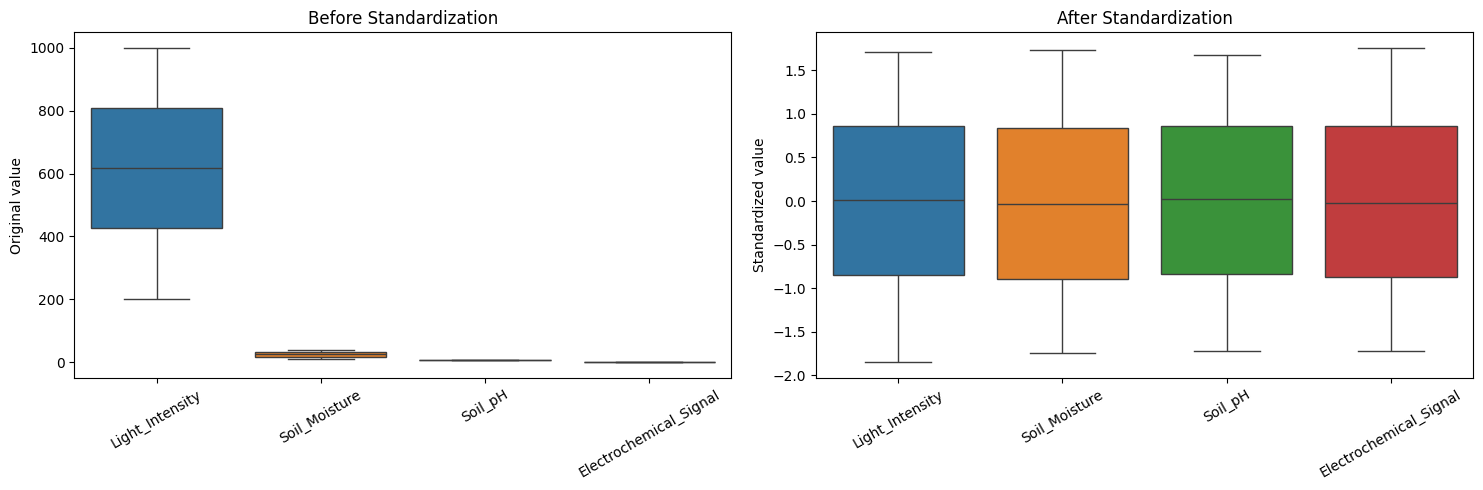

In [13]:
import os

os.makedirs(
    "results/eda_visualizations",
    exist_ok=True
)

selected_features = [
    "Light_Intensity",
    "Soil_Moisture",
    "Soil_pH",
    "Electrochemical_Signal"
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5)
)

sns.boxplot(
    data=X_train[selected_features],
    ax=axes[0]
)

axes[0].set_title("Before Standardization")
axes[0].set_ylabel("Original value")
axes[0].tick_params(axis="x", rotation=30)

sns.boxplot(
    data=X_train_scaled_demo[selected_features],
    ax=axes[1]
)

axes[1].set_title("After Standardization")
axes[1].set_ylabel("Standardized value")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()

plt.savefig(
    "results/eda_visualizations/"
    "standardization_before_after.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Standardization Output Interpretation

Before standardization, Light Intensity had a much larger numerical range than Soil pH and Electrochemical Signal. This caused the smaller features to appear compressed in the original visualization.

After StandardScaler, the features were placed on comparable numerical scales. The verification output showed means close to zero and standard deviations close to one. This transformation is appropriate for SVM because SVM is sensitive to differences in feature scale.

In [14]:
svm_pipeline = Pipeline([
    (
        "missing_values",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        SVC(class_weight="balanced")
    )
])

# **Conclusion**

I fitted StandardScaler using only the training data and used the same fitted scaler to transform the test data. This prevented data leakage. The output verification showed that the standardized features had means close to zero and standard deviations close to one.

The EDA visualizations showed that soil moisture and nitrogen were associated with plant health status. Healthy observations generally had higher soil moisture, while High Stress observations generally had lower soil moisture. Standardization prepared these numeric features for the SVM model without removing the original information.

In [15]:
os.makedirs(
    "results/outputs",
    exist_ok=True
)

processed_training_data = X_train_scaled_demo.copy()
processed_training_data["Plant_Health_Status"] = y_train.values
processed_training_data["Plant_ID"] = groups_train.values

processed_testing_data = X_test_scaled_demo.copy()
processed_testing_data["Plant_Health_Status"] = y_test.values
processed_testing_data["Plant_ID"] = groups_test.values

processed_training_data.to_csv(
    "results/outputs/standardized_training_data.csv",
    index=False
)

processed_testing_data.to_csv(
    "results/outputs/standardized_testing_data.csv",
    index=False
)

print("Standardized output files saved successfully.")

Standardized output files saved successfully.
